# K-Nearest Neighboard

Ý tưởng rất đơn giản, đó là trong nhiều nhóm đối tượng thì tìm nhiều đối tượng trong một nhóm nào đó nhất thì coi như thuộc nhóm đó. KNN thường được áp dụng cho bài toán phân loại (classification)
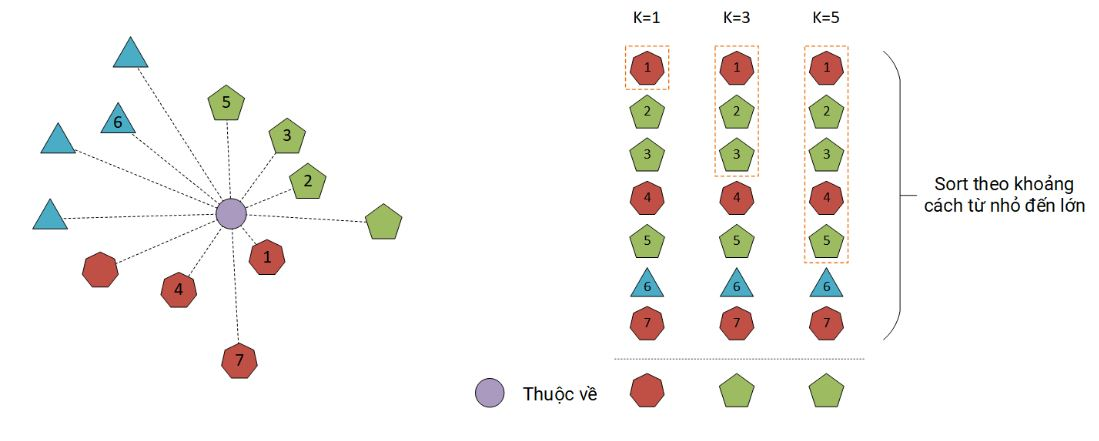

Giả định, đầu tiên ta có một tập dữ liệu $X\_train$. Sau đó, chọn một tube dữ liệu từ tập $X\_test$ gọi là $x^*$:


- Tính khoảng cách của $x^*$ với tất cả các phần tử $x_i$ trong tập $X\_train$
- Sắp xếp các khoảng cách này theo thứ tự tăng dần (từ nhỏ đến lớn)
- Lấy ra $k$ khoảng cách đầu tiên (nearest)
- Đếm số lần xuất hiện của các label tương ứng với $k$ khoảng cách đầu tiên đó. Cái label nào xuất hiện nhiều hơn thì chọn


Tổng quát: cho $\overrightarrow{P} = (p_1,p_2,\cdots,p_n)$ và $\overrightarrow{Q} = (q_1, q_2, \cdots, q_n)$


$$
\Large L_1 \;norm=\sum_{i=1}^n \mid p_i - q_i \mid  \tag{Manhattan distance}
$$


$$
\Large L_2 \;norm=\sqrt{\sum_{i=1}^n (p_i - q_i)^2} \tag{Euclidean distance}
$$


$$
\Large L_k \;norm=\sqrt[\leftroot{5}\uproot{-3}{k}]{\sum_{i=1}^n (\mid p_i - q_i\mid)^k}=\biggl[{\sum_{i=1}^n (\mid p_i - q_i\mid)^k}\biggr]^{\frac{1}{k}}
$$

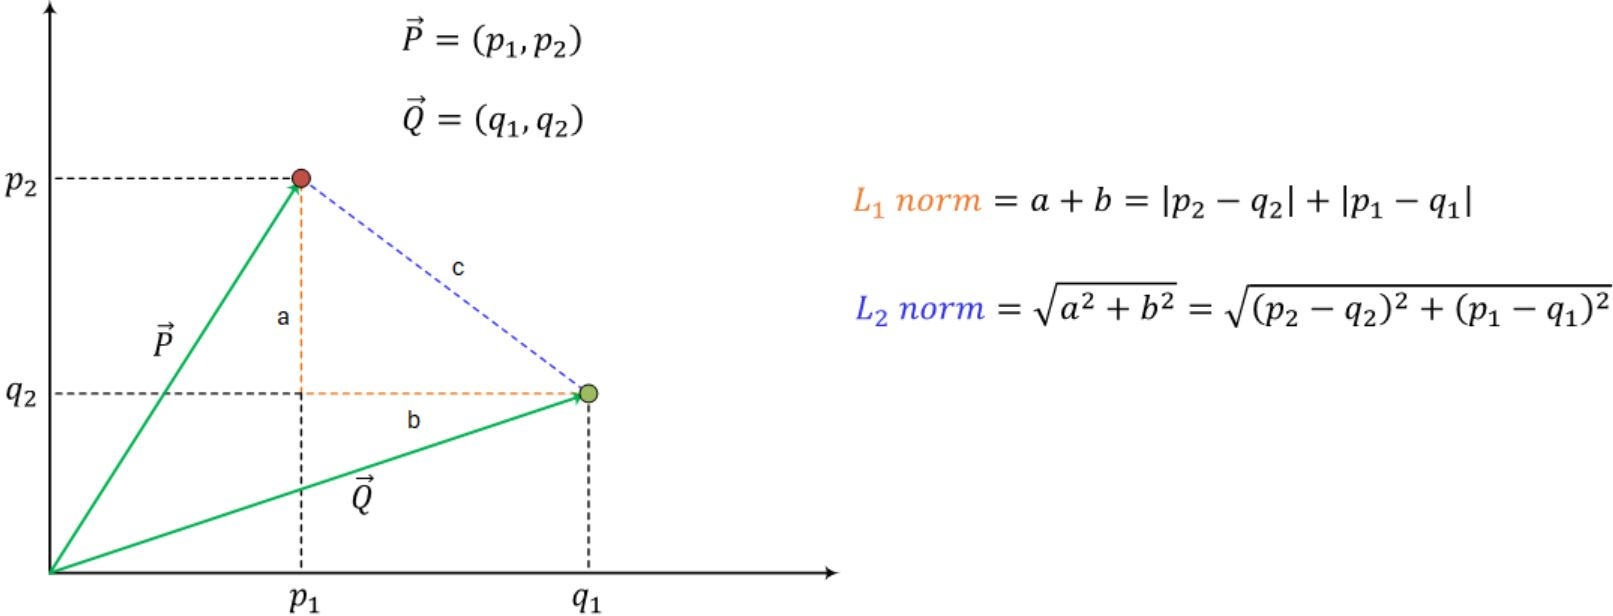

## 1. Nạp thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Nạp dữ liệu

In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/2321004059_PhanHongPhuc_KPDL/Chuong4/KNN/data/Data_classification.csv')
dataset.head(5)

,Unnamed: 0,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1000 non-null   int64  
 1   WTT           1000 non-null   float64
 2   PTI           1000 non-null   float64
 3   EQW           1000 non-null   float64
 4   SBI           1000 non-null   float64
 5   LQE           1000 non-null   float64
 6   QWG           1000 non-null   float64
 7   FDJ           1000 non-null   float64
 8   PJF           1000 non-null   float64
 9   HQE           1000 non-null   float64
 10  NXJ           1000 non-null   float64
 11  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 93.9 KB


In [5]:
dataset.describe()

,Unnamed: 0,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,499.500000,0.949682,1.114303,0.834127,0.682099,1.032336,0.943534,0.963422,1.071960,1.158251,1.362725,0.50000
std,288.819436,0.289635,0.257085,0.291554,0.229645,0.243413,0.256121,0.255118,0.288982,0.293738,0.204225,0.50025
min,0.000000,0.174412,0.441398,0.170924,0.045027,0.315307,0.262389,0.295228,0.299476,0.365157,0.639693,0.00000
25%,249.750000,0.742358,0.942071,0.615451,0.515010,0.870855,0.761064,0.784407,0.866306,0.934340,1.222623,0.00000
50%,499.500000,0.940475,1.118486,0.813264,0.676835,1.035824,0.941502,0.945333,1.065500,1.165556,1.375368,0.50000
75%,749.250000,1.163295,1.307904,1.028340,0.834317,1.198270,1.123060,1.134852,1.283156,1.383173,1.504832,1.00000
max,999.000000,1.721779,1.833757,1.722725,1.634884,1.650050,1.666902,1.713342,1.785420,1.885690,1.893950,1.00000


In [7]:
#Tiền xử lý xóa cột uname
dataset = dataset.drop(columns='Unnamed: 0')

In [8]:
#kiem trau unique lcass
dataset['TARGET CLASS'].unique()

array([1, 0])

## 3. Tách biến độc lập và biến phụ

In [9]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [10]:
X[:5]

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167


In [11]:
y[:5]

,TARGET CLASS
0,1
1,0
2,0
3,1
4,1


## 4. Phân chia tập

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state=0)

In [13]:
X_train.shape

(800, 10)

In [14]:
X_test.shape

(200, 10)

## 5. Chuẩn hóa dữ liệu (bắt buộc phải có với KNN) tuy nhiên dữ liệu chỉ có 1 đặc trưng nên bỏ qua bước này

In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 6.Chọn K cho mô hình KNN

In [16]:
from os import error
#giả sử chọn K =3
error_rate = []
from sklearn.neighbors import KNeighborsClassifier
for i in range(1,40):
  classifier = KNeighborsClassifier(n_neighbors=i,metric='minkowski')
  classifier.fit(X_train,y_train)
  y_pred = classifier.predict(X_test)
  error_rate.append(np.mean(y_pred != y_test))

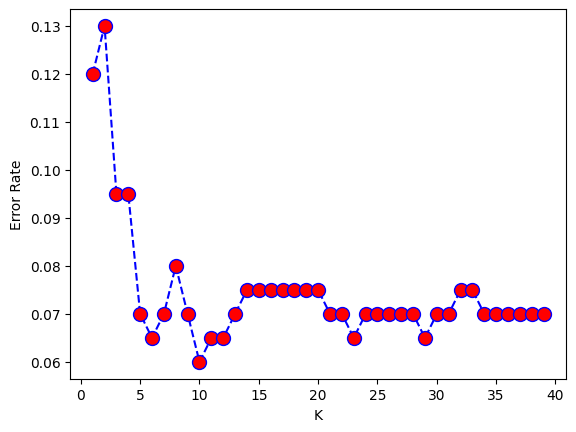

In [17]:
#Trực quan hóa độ lỗi của KNN
plt.plot(range(1,40),error_rate,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=10)
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [18]:
error_rate.index(min(error_rate)) + 1

10

In [19]:
#Sau khi xác định K, tiến hành huấn luyện mô hình với K=1
classifier = KNeighborsClassifier(n_neighbors=10,metric='minkowski')
classifier.fit(X_train,y_train)


KNeighborsClassifier(n_neighbors=10)

## 7. Dự đoán tập kiểm thử

In [20]:
y_pred = classifier.predict(X_test)
print(y_pred)
print(y_test)

[1 0 0 1 1 0 1 0 1 1 0 1 0 1 1 0 1 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 1 1 1 1
 1 1 1 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 1 1 1 0 1 0 0 1 1 1 0 0 1 1 0 1 1 1 1
 1 1 0 1 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0
 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 1 1 0 0 1 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 0
 0 0 1 1 1 0 0 0 0 1 1 1 1 1 1]
993    1
859    0
298    0
553    1
672    1
      ..
679    1
722    1
215    1
653    1
150    1
Name: TARGET CLASS, Length: 200, dtype: int64


## 8.Đánh giá mô hình

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
cm = confusion_matrix(y_test,y_pred)
df_cm = pd.DataFrame(cm,index=['Actual: 0','Actual: 1'],columns=['Pred: 0','Pred: 1'])
display(df_cm)
#
accuracy_score(y_test,y_pred)
precision_score(y_test,y_pred)
recall_score(y_test,y_pred)
f1_score(y_test,y_pred)
#

,Pred: 0,Pred: 1
Actual: 0,80,6
Actual: 1,6,108


0.9473684210526315